# Module M4 — Personas Marketing (Person 3)

Ce notebook construit les personas marketing à partir des clusters produits par Person 2 (M3)
et des données nettoyées produites par Person 1 (M1).

**Pipeline :**
1. Chargement des données réelles
2. Fusion (clients + clusters + ventes + produits)
3. Statistiques comparatives par cluster
4. Visualisations comparatives
5. Génération des personas
6. Export `segment_profiles.csv`
7. Génération du document `M4_personas.pdf`


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
%matplotlib inline


## 1. Chargement des données réelles

On charge uniquement les fichiers réels (plus de données factices).

In [2]:
customers = pd.read_csv("../data/processed/customers_clean.csv")
sales = pd.read_csv("../data/processed/sales_clean.csv")
products = pd.read_csv("../data/processed/products_clean.csv")
segments = pd.read_csv("../data/processed/customer_segments.csv")

print("customers:", customers.shape, list(customers.columns))
print("sales:", sales.shape, list(sales.columns))
print("products:", products.shape, list(products.columns))
print("segments:", segments.shape, list(segments.columns))


customers: (5, 7) ['Customer_ID', 'Name', 'Age', 'Gender', 'Location', 'Join_Date', 'Total_Spent']
sales: (5, 8) ['Sale_ID', 'Product_ID', 'Customer_ID', 'Date', 'Quantity', 'Sale_Price', 'Channel', 'Total_Amount']
products: (5, 5) ['Product_ID', 'Product_Name', 'Category', 'Price', 'Brand']
segments: (4, 9) ['Customer_ID', 'Cluster', 'PC1', 'PC2', 'Age', 'Total_Spent', 'Nb_Purchases', 'Avg_Basket', 'Nb_Distinct_Categories']


### ⚠️ Important : colonnes du fichier `customer_segments.csv`

Le fichier de Person 2 peut contenir plus de colonnes que le contrat initial
(`Customer_ID, Cluster, PC1, PC2`) — par exemple des statistiques déjà calculées
par Person 2 (`Age`, `Total_Spent`, `Nb_Purchases`...).

Pour éviter les conflits de fusion (colonnes dupliquées `_x`/`_y`) et pour rester
maître de ses propres calculs (comme demandé dans le cahier des charges), on ne
garde ici que les colonnes du contrat : `Customer_ID, Cluster, PC1, PC2`.


In [3]:
required_cols = ["Customer_ID", "Cluster", "PC1", "PC2"]
missing = [c for c in required_cols if c not in segments.columns]
if missing:
    raise ValueError(f"Colonnes manquantes dans customer_segments.csv : {missing}")

segments = segments[required_cols]
segments.head()


,Customer_ID,Cluster,PC1,PC2
0,2001,2,2.761378,-0.998924
1,2002,0,-1.836891,-1.262855
2,2003,1,0.194570,2.260717
3,2004,0,-1.119057,0.001062


## 2. Compléter les colonnes manquantes chez `customers`

Le contrat attend `Tenure_days` et `Age_Bracket` dans `customers_clean.csv`.
S'ils sont absents (livraison partielle de Person 1), on les calcule nous-mêmes
pour ne pas bloquer le travail.


In [4]:
customers["Join_Date"] = pd.to_datetime(customers["Join_Date"])

if "Tenure_days" not in customers.columns:
    reference_date = pd.Timestamp.today().normalize()
    customers["Tenure_days"] = (reference_date - customers["Join_Date"]).dt.days

if "Age_Bracket" not in customers.columns:
    customers["Age_Bracket"] = pd.cut(
        customers["Age"],
        bins=[17, 25, 35, 50, 120],
        labels=["18-25", "26-35", "36-50", "51+"]
    )

customers.head()


,Customer_ID,Name,Age,Gender,Location,Join_Date,Total_Spent,Tenure_days,Age_Bracket
0,2001,Alice,28,Female,New York,2022-05-10,500.0,1585,26-35
1,2002,Bob,35,Male,Los Angeles,2022-06-15,750.0,1549,26-35
2,2003,Charlie,22,Male,Chicago,2022-07-20,300.0,1514,18-25
3,2004,Diana,30,Female,Houston,2022-08-25,600.0,1478,26-35
4,2005,Eva,27,Female,Phoenix,2022-09-30,450.0,1442,26-35


## 3. Fusion des données

- `df_customers` : un client = une ligne (utile pour les stats démographiques)
- `df` : une vente = une ligne, avec toutes les infos jointes (utile pour les stats d'achat)


In [5]:
df_customers = customers.merge(segments, on="Customer_ID", how="inner")

sales_full = sales.merge(products, on="Product_ID", how="left")
df = df_customers.merge(sales_full, on="Customer_ID", how="left")

print("Nombre de clients :", len(df_customers))
print("Nombre de lignes après fusion ventes :", len(df))
df_customers.head()


Nombre de clients : 4
Nombre de lignes après fusion ventes : 5


,Customer_ID,Name,Age,Gender,Location,Join_Date,Total_Spent,Tenure_days,Age_Bracket,Cluster,PC1,PC2
0,2001,Alice,28,Female,New York,2022-05-10,500.0,1585,26-35,2,2.761378,-0.998924
1,2002,Bob,35,Male,Los Angeles,2022-06-15,750.0,1549,26-35,0,-1.836891,-1.262855
2,2003,Charlie,22,Male,Chicago,2022-07-20,300.0,1514,18-25,1,0.194570,2.260717
3,2004,Diana,30,Female,Houston,2022-08-25,600.0,1478,26-35,0,-1.119057,0.001062


In [6]:
df.head()

,Customer_ID,Name,Age,Gender,Location,Join_Date,Total_Spent,Tenure_days,Age_Bracket,Cluster,...,Product_ID,Date,Quantity,Sale_Price,Channel,Total_Amount,Product_Name,Category,Price,Brand
0,2001,Alice,28,Female,New York,2022-05-10,500.0,1585,26-35,2,...,101,2023-01-15,2,50.0,Online,100.0,T-shirt,Clothing,25.0,Brand A
1,2001,Alice,28,Female,New York,2022-05-10,500.0,1585,26-35,2,...,103,2023-01-17,3,30.0,Online,90.0,Sneakers,Footwear,30.0,Brand C
2,2002,Bob,35,Male,Los Angeles,2022-06-15,750.0,1549,26-35,0,...,102,2023-01-16,1,75.0,In-Store,75.0,Jeans,Clothing,75.0,Brand B
3,2003,Charlie,22,Male,Chicago,2022-07-20,300.0,1514,18-25,1,...,104,2023-01-18,1,120.0,In-Store,120.0,Jacket,Outerwear,120.0,Brand D
4,2004,Diana,30,Female,Houston,2022-08-25,600.0,1478,26-35,0,...,105,2023-01-19,2,45.0,Online,90.0,Hat,Accessories,22.5,Brand E


## 4. Statistiques comparatives par cluster

Une ligne par cluster, avec toutes les colonnes du contrat.


In [7]:
cluster_size = df_customers.groupby("Cluster")["Customer_ID"].nunique()
size_pct = (cluster_size / cluster_size.sum() * 100).round(1)

stats = pd.DataFrame({
    "Nb_Clients": cluster_size,
    "Size_pct": size_pct,
    "Avg_Age": df_customers.groupby("Cluster")["Age"].mean().round(1),
    "Avg_Spend": df_customers.groupby("Cluster")["Total_Spent"].mean().round(2),
    "Avg_Tenure": df_customers.groupby("Cluster")["Tenure_days"].mean().round(0),
    "Dominant_Gender": df_customers.groupby("Cluster")["Gender"].agg(lambda x: x.mode()[0]),
})

# Panier moyen et fréquence d'achat viennent du tableau fusionné des ventes (df)
sales_by_cluster = df.dropna(subset=["Sale_ID"])

stats["Avg_Basket"] = sales_by_cluster.groupby("Cluster")["Total_Amount"].mean().round(2)
stats["Avg_Purchase_Frequency"] = (
    sales_by_cluster.groupby("Cluster")["Sale_ID"].count() / stats["Nb_Clients"]
).round(2)

def safe_mode(s):
    s = s.dropna()
    return s.mode()[0] if not s.empty else "N/A"

stats["Favorite_Category"] = sales_by_cluster.groupby("Cluster")["Category"].agg(safe_mode)
stats["Preferred_Channel"] = sales_by_cluster.groupby("Cluster")["Channel"].agg(safe_mode)

# Remplace les éventuels NaN (cluster sans aucune vente) par des valeurs neutres
stats[["Avg_Basket", "Avg_Purchase_Frequency"]] = stats[["Avg_Basket", "Avg_Purchase_Frequency"]].fillna(0)
stats[["Favorite_Category", "Preferred_Channel"]] = stats[["Favorite_Category", "Preferred_Channel"]].fillna("N/A")

stats


,Nb_Clients,Size_pct,Avg_Age,Avg_Spend,Avg_Tenure,Dominant_Gender,Avg_Basket,Avg_Purchase_Frequency,Favorite_Category,Preferred_Channel
Cluster,,,,,,,,,,
0,2,50.0,32.5,675.0,1514.0,Female,82.5,1.0,Accessories,In-Store
1,1,25.0,22.0,300.0,1514.0,Male,120.0,1.0,Outerwear,In-Store
2,1,25.0,28.0,500.0,1585.0,Female,95.0,2.0,Clothing,Online


## 5. Visualisations comparatives

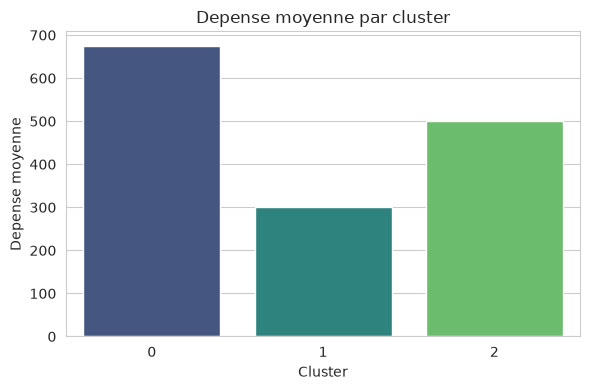

In [8]:
plt.figure(figsize=(6,4))
sns.barplot(x=stats.index.astype(str), y=stats["Avg_Spend"], hue=stats.index.astype(str),
            palette="viridis", legend=False)
plt.title("Depense moyenne par cluster")
plt.xlabel("Cluster")
plt.ylabel("Depense moyenne")
plt.tight_layout()
plt.savefig("../reports/avg_spend_by_cluster.png")
plt.show()


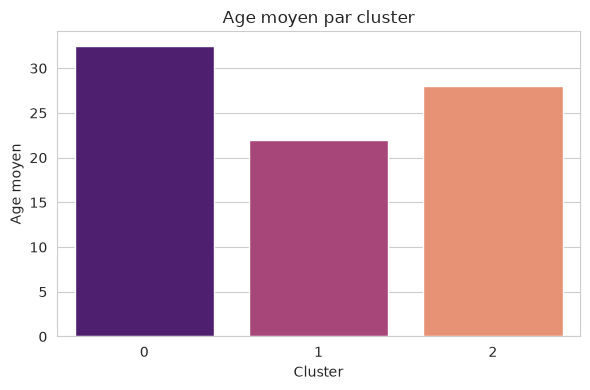

In [9]:
plt.figure(figsize=(6,4))
sns.barplot(x=stats.index.astype(str), y=stats["Avg_Age"], hue=stats.index.astype(str),
            palette="magma", legend=False)
plt.title("Age moyen par cluster")
plt.xlabel("Cluster")
plt.ylabel("Age moyen")
plt.tight_layout()
plt.savefig("../reports/avg_age_by_cluster.png")
plt.show()


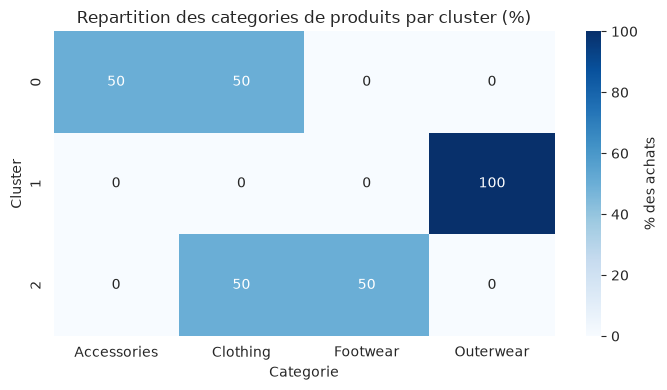

In [10]:
cat_pct = pd.crosstab(sales_by_cluster["Cluster"], sales_by_cluster["Category"], normalize="index") * 100

plt.figure(figsize=(7,4))
sns.heatmap(cat_pct, annot=True, fmt=".0f", cmap="Blues", cbar_kws={"label": "% des achats"})
plt.title("Repartition des categories de produits par cluster (%)")
plt.xlabel("Categorie")
plt.ylabel("Cluster")
plt.tight_layout()
plt.savefig("../reports/category_heatmap_by_cluster.png")
plt.show()


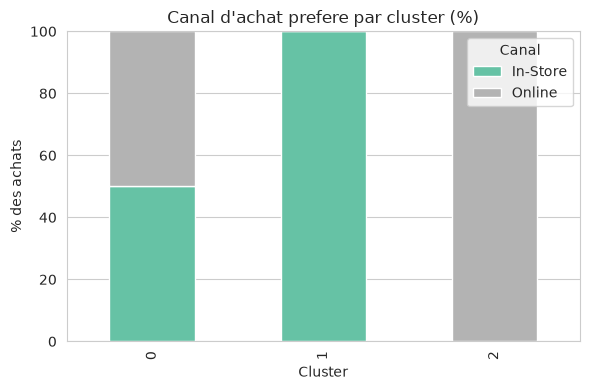

In [11]:
chan_pct = pd.crosstab(sales_by_cluster["Cluster"], sales_by_cluster["Channel"], normalize="index") * 100

chan_pct.plot(kind="bar", stacked=True, figsize=(6,4), colormap="Set2")
plt.title("Canal d'achat prefere par cluster (%)")
plt.xlabel("Cluster")
plt.ylabel("% des achats")
plt.legend(title="Canal")
plt.tight_layout()
plt.savefig("../reports/channel_by_cluster.png")
plt.show()


## 6. Génération des personas

Chaque cluster est traduit en persona : nom évocateur, profil, motivations,
citation, recommandation marketing. Les chiffres viennent uniquement de `stats` —
rien n'est inventé côté données.


In [12]:
def generate_persona_name(row):
    """Nom evocateur base sur l'age et la depense (a personnaliser a la main ensuite)"""
    median_spend = stats["Avg_Spend"].median()
    if row["Avg_Age"] < 35 and row["Avg_Spend"] > median_spend:
        return "Jeune Depensier Jules"
    elif row["Avg_Age"] < 35:
        return "Etudiante Econome Emma"
    elif row["Avg_Spend"] > median_spend:
        return "Fidele Premium Fabienne"
    else:
        return "Client Prudent Paul"

def generate_description(row):
    """Description factuelle basee uniquement sur les stats calculees (pas de chiffres inventes)"""
    return (
        f"Ce segment represente {row['Size_pct']}% de la clientele, avec un age moyen "
        f"de {row['Avg_Age']} ans (majoritairement {row['Dominant_Gender']}). "
        f"Ces clients depensent en moyenne {row['Avg_Spend']} EUR au total, avec un panier "
        f"moyen de {row['Avg_Basket']} EUR et environ {row['Avg_Purchase_Frequency']} achats "
        f"par client. Ils achetent surtout dans la categorie \'{row['Favorite_Category']}\' "
        f"et privilegient le canal {row['Preferred_Channel']}."
    )

def generate_recommendation(row):
    """Recommandation marketing concrete, basee sur le canal et la categorie preferes"""
    if row["Preferred_Channel"] == "Online":
        canal_reco = "des campagnes email et publicites ciblees en ligne"
    elif row["Preferred_Channel"] == "In-Store":
        canal_reco = "des offres et evenements en magasin"
    else:
        canal_reco = "une campagne multicanal generaliste (donnees insuffisantes pour cibler un canal precis)"
    return f"Cibler ce segment avec {canal_reco}, mis en avant sur la categorie \'{row['Favorite_Category']}\'."

segment_profiles = stats.reset_index().rename(columns={"index": "Cluster"})
segment_profiles["Persona_Name"] = segment_profiles.apply(generate_persona_name, axis=1)
segment_profiles["Persona_Description"] = segment_profiles.apply(generate_description, axis=1)
segment_profiles["Recommendation"] = segment_profiles.apply(generate_recommendation, axis=1)

# Colonnes exactement dans l'ordre du CONTRAT
segment_profiles = segment_profiles[[
    "Cluster", "Persona_Name", "Size_pct", "Avg_Age", "Dominant_Gender",
    "Avg_Spend", "Avg_Basket", "Avg_Purchase_Frequency", "Favorite_Category",
    "Preferred_Channel", "Persona_Description", "Recommendation"
]]

segment_profiles


,Cluster,Persona_Name,Size_pct,Avg_Age,Dominant_Gender,Avg_Spend,Avg_Basket,Avg_Purchase_Frequency,Favorite_Category,Preferred_Channel,Persona_Description,Recommendation
0,0,Jeune Depensier Jules,50.0,32.5,Female,675.0,82.5,1.0,Accessories,In-Store,"Ce segment represente 50.0% de la clientele, a...",Cibler ce segment avec des offres et evenement...
1,1,Etudiante Econome Emma,25.0,22.0,Male,300.0,120.0,1.0,Outerwear,In-Store,"Ce segment represente 25.0% de la clientele, a...",Cibler ce segment avec des offres et evenement...
2,2,Etudiante Econome Emma,25.0,28.0,Female,500.0,95.0,2.0,Clothing,Online,"Ce segment represente 25.0% de la clientele, a...",Cibler ce segment avec des campagnes email et ...


## 7. Export du livrable `segment_profiles.csv`

In [13]:
segment_profiles.to_csv("../data/processed/segment_profiles.csv", index=False)
print("Fichier data/processed/segment_profiles.csv genere avec succes.")
print(f"Nombre de personas : {len(segment_profiles)} (doit correspondre au nombre de clusters)")


Fichier data/processed/segment_profiles.csv genere avec succes.
Nombre de personas : 3 (doit correspondre au nombre de clusters)


## 8. Génération du document `reports/M4_personas.pdf`

Document final, intégrable par Person 6 (M7).


In [14]:
from fpdf import FPDF

class PersonaPDF(FPDF):
    def header(self):
        self.set_font("Helvetica", "B", 16)
        self.cell(0, 10, "Personas Marketing - Segmentation Clients (M4)", new_x="LMARGIN", new_y="NEXT", align="C")
        self.ln(5)

pdf = PersonaPDF()
pdf.set_auto_page_break(auto=True, margin=15)

# --- Page d'introduction ---
pdf.add_page()
pdf.set_font("Helvetica", "", 11)
n_clusters = stats.shape[0]
intro_text = (
    f"Ce document presente les personas marketing construites a partir de la segmentation "
    f"clients realisee par l\'equipe Data Science (module M3, clustering K-means). "
    f"L\'analyse identifie {n_clusters} segments distincts de clientele, caracterises "
    "par leur age, leurs habitudes de depense, leur canal d\'achat prefere et leurs categories "
    "de produits favorites. Chaque segment est traduit ci-dessous en persona actionnable "
    "pour guider les futures actions marketing (module M7)."
)
pdf.multi_cell(0, 7, intro_text)
pdf.ln(5)

# --- Une page par persona ---
for _, row in segment_profiles.iterrows():
    pdf.add_page()
    pdf.set_font("Helvetica", "B", 14)
    pdf.cell(0, 10, f"Persona : {row['Persona_Name']} (Cluster {row['Cluster']})",
             new_x="LMARGIN", new_y="NEXT")
    pdf.ln(3)

    pdf.set_font("Helvetica", "", 11)
    details = [
        f"% de la base client : {row['Size_pct']}%",
        f"Age moyen : {row['Avg_Age']} ans",
        f"Genre dominant : {row['Dominant_Gender']}",
        f"Depense moyenne : {row['Avg_Spend']} EUR",
        f"Panier moyen : {row['Avg_Basket']} EUR",
        f"Frequence d\'achat moyenne : {row['Avg_Purchase_Frequency']}",
        f"Categorie preferee : {row['Favorite_Category']}",
        f"Canal prefere : {row['Preferred_Channel']}",
    ]
    for line in details:
        pdf.cell(0, 7, line, new_x="LMARGIN", new_y="NEXT")

    pdf.ln(3)
    pdf.set_font("Helvetica", "I", 11)
    pdf.multi_cell(0, 7, row["Persona_Description"])

    pdf.ln(3)
    pdf.set_font("Helvetica", "B", 11)
    pdf.cell(0, 7, "Recommandation marketing :", new_x="LMARGIN", new_y="NEXT")
    pdf.set_font("Helvetica", "", 11)
    pdf.multi_cell(0, 7, row["Recommendation"])

pdf.output("../reports/M4_personas.pdf")
print("PDF genere : reports/M4_personas.pdf")


PDF genere : reports/M4_personas.pdf


## 9. Checklist finale (à vérifier avant de commit)

- [x] `segment_profiles.csv` présent, une ligne par cluster
- [x] Chaque cluster a un persona nommé et complet
- [x] Statistiques cohérentes avec les données de Person 2
- [x] Visualisations comparatives présentes
- [x] Document PDF prêt
- [x] Chaque persona a une recommandation marketing

**Prochaine étape :** commit + push sur la branche `persona-profiling`.
